# <center>Ciencia de datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Redes Neuronales</center>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randint
from numpy import linspace

np.random.seed(1)

## El proceso de aprendizaje de una red neuronal

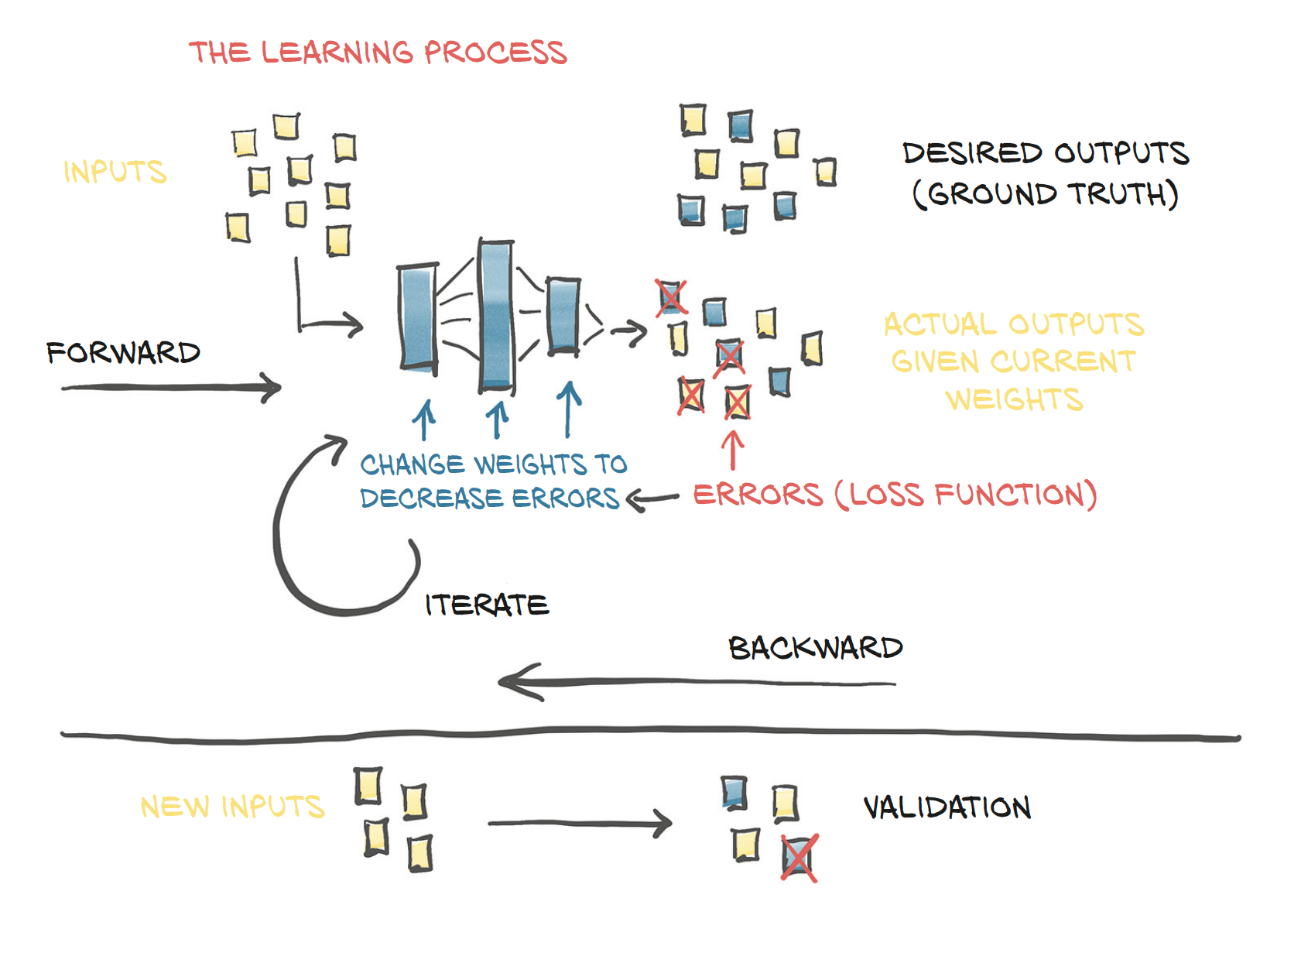

Fuente: Stevens et al. 2020, Capítulo 5


### Descenso por gradiente

El descenso por gradiente es un algoritmo de optimización fundamental utilizado en las redes neuronales para minimizar la función de costo (o error) de un modelo. Funciona ajustando iterativamente los pesos y sesgos de la red en la dirección opuesta al gradiente de la función de costo, es decir, la dirección de mayor descenso. De esta manera, el modelo 'aprende' a hacer predicciones más precisas con cada iteración.

![gd3.png](https://www.researchgate.net/profile/Fernando-De-La-Rosa/publication/308783857/figure/fig1/AS:530004720013312@1503374380809/Optimizacion-gradiente-de-descenso4-Este-gradiente-es-hallado-despues-de-ejecutar-el.png)

Hallar el mínimo de la siguiente función utilizando descenso por gradiente $$y = x^2 + 1$$

In [7]:
def descenso_gradiente(learning_rate,n_iteraciones):
    x_inicial = randint(10)

    iteraciones = []
    y = []

    x = x_inicial
    for i in range(n_iteraciones):
        # print('------------------------')
        # print('iteración ', str(i+1))

        # Calcular gradiente
        gradiente = 2*x

        # Actualizar "x" usando gradiente descendente
        x = x - learning_rate*gradiente

        # Almacenar iteración y valor correspondiente
        y_iteracion=x**2 + 1
        y.append(y_iteracion)
        iteraciones.append(i+1)

    return iteraciones,y

Este gráfico compara cómo diferentes tasas de aprendizaje (**Learning Rate**) afectan la velocidad con la que el algoritmo encuentra el mínimo.

Learning Rate 0.001: Y inicial = 25.9001, Y final = 1.4561
Learning Rate 0.01: Y inicial = 62.4656, Y final = 1.0000


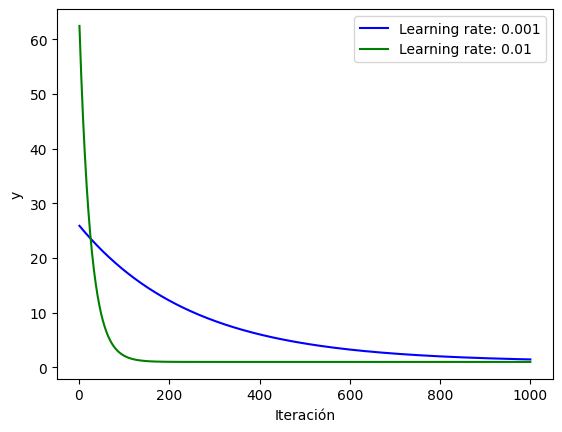

In [8]:
n_iteraciones = 1000


iteraciones1,y1=descenso_gradiente(0.001,n_iteraciones)
iteraciones2,y2=descenso_gradiente(0.01,n_iteraciones)

plt.plot(iteraciones1, y1, color='blue', label='Learning rate: 0.001')
plt.plot(iteraciones2, y2, color='green', label='Learning rate: 0.01')
plt.xlabel('Iteración')
plt.ylabel('y')
plt.legend()


print(f"Learning Rate 0.001: Y inicial = {y1[0]:.4f}, Y final = {y1[-1]:.4f}")
print(f"Learning Rate 0.01: Y inicial = {y2[0]:.4f}, Y final = {y2[-1]:.4f}")

El **Descenso por Gradiente** es fundamental porque es el algoritmo de optimización que permite a las redes neuronales 'aprender'. Funciona calculando la dirección de máxima pendiente (gradiente) de la función de error y dando pasos en la dirección opuesta.

El gráfico muestra cómo:

*   Una tasa de aprendizaje más alta (verde) converge más rápido pero corre el riesgo de 'pasarse' del mínimo.
*   Una tasa de aprendizaje más baja (azul) es más estable pero requiere muchas más iteraciones para llegar al mismo resultado.

Los valores iniciales y finales de `Y` muestran cómo la función de costo evolucionó para cada tasa de aprendizaje. Una tasa de aprendizaje de más alta converge más rápidamente al mínimo (Y final cercano a 1.0) en menos iteraciones comparado con una mas alta.

## Visualización del modelo de regresión lineal y la superficie del error

Funciones auxiliares (solo ejecutar, y seguir más abajo)

In [9]:
###############################################################################
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
###############################################################################

def visualizar_superficie_error(ax_surface,x,y,m,b,mean_error):
    ax_surface.set_xlabel('m')
    ax_surface.set_ylabel('b')
    ax_surface.set_zlabel('Error')
    ax_surface.set_title('Superficie de Error E(m,b)')

    detail = 0.5
    param_range = 20
    M = np.arange(m - param_range, m + param_range, detail)
    B = np.arange(b - param_range, b + param_range, detail)
    Ms, Bs = np.meshgrid(M, B)

    E = np.zeros_like(Ms)
    for i in range(len(x)):
        E += (Ms * x[i] + Bs - y[i])**2
    E /= len(x)

    surf = ax_surface.plot_surface(Ms, Bs, E, cmap=cm.coolwarm, alpha=0.7, linewidth=0)
    ax_surface.scatter([m], [b], [mean_error], color='green', s=100, label='Posición actual')

def visualizar(x,y,m,b,y_predicted,errors,mean_error,new_x,new_y,ver_residuos,ver_nuevo_dato):
    fig = plt.figure(figsize=(12, 6))

    # Gráfico 2D de los datos y la recta
    ax2d = fig.add_subplot(1, 2, 1)
    ax2d.scatter(x, y, color='blue', label='Datos')
    ax2d.plot(x, y_predicted, color='red', label='Modelo (mx+b)')
    if ver_residuos:
        for i in range(len(x)):
            ax2d.plot([x[i], x[i]], [y[i], y_predicted[i]], color='gray', linestyle='--', alpha=0.5)
    ax2d.set_title(f'Ajuste Lineal - Error: {mean_error:.4f}')
    ax2d.legend()

    # Gráfico 3D de la superficie de error
    ax3d = fig.add_subplot(1, 2, 2, projection='3d')
    visualizar_superficie_error(ax3d, x, y, m, b, mean_error)

    plt.tight_layout()
    plt.show()



El siguiente código carga un conjunto de datos, y luego crea un modelo de regresión lineal para predecir los valores de salida `y` en base a los de entrada `x` con la función `y=mx+b`.

**A continuación, se encuentra:**
1.  Una celda de **configuración común** que carga los datos y define los parámetros iniciales.
2.  Una sección para el ejemplo **sin normalización**.
3.  Una sección para el ejemplo **con normalización**.

Probá modificando los parámetros `m` y `b` del modelo en la celda de configuración común, tratando de minimizar *a mano* el error. Observá cómo cambia la recta `mx+b` y qué tan bien se ajusta a los datos (izquierda) y al mismo tiempo cambia la posición de los parámetros en la función de error (bola verde/turquesa en la figura de la derecha).

Notá que la forma de la superficie del error (un paraboloide) no cambia al modificar los parámetros (derecha). Lo que sí cambia es la posición de los mismos en el espacio de todas las posibles combinaciones de `m` y `b`.


In [10]:
# Carga de datos común y definición de parámetros iniciales
dataset_base=""
dataset="study_regression_small.csv"
dataset_path=os.path.join(dataset_base,dataset)
data=np.loadtxt(open(dataset_path, "rb"), delimiter=",", skiprows=1)
x_original,y_original=data[:,0],data[:,1]

## Parámetros del modelo. Probar valores del rango [-10, 10]
m=9
b=-4

# Dato nuevo a evaluar
new_x=1

#Opciones de visualización (deshabilitar para ver mejor los datos)
ver_residuos=True
ver_nuevo_dato=True

In [11]:
x_original,y_original

(array([ 2. ,  5. ,  7. ,  9. , 10. , 11. , 13.4, 14. , 15. , 17. , 19. ,
        22. , 25. , 29. , 31. , 33. , 35. , 40. , 42. ]),
 array([ 1. ,  3.2,  4.5,  6. ,  4. ,  4.5,  5.5,  3. ,  5. ,  5. ,  6. ,
         7. ,  7. ,  9.1,  5.4,  7. , 10. , 10. ,  9.1]))

### Ejemplo sin normalización

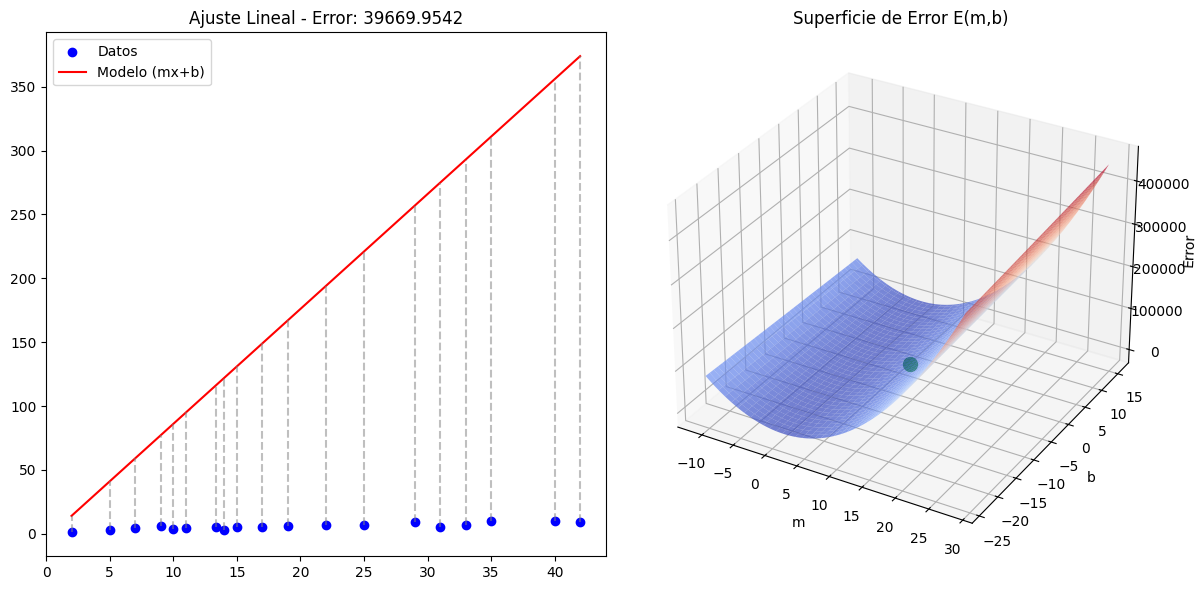

In [12]:
# Usamos los datos originales sin normalizar
x = x_original.copy()
y = y_original.copy()

# Cálculo de la salida o predicción del modelo para todos los ejemplos
y_predicted= x*m+b

# Calculo del error del modelo
errors= (y-y_predicted)**2
mean_error=errors.mean()

# Dato nuevo a evaluar con los parámetros actuales
new_y=new_x*m+b

# Visualizar
visualizar(x,y,m,b,y_predicted,errors,mean_error,new_x,new_y,ver_residuos,ver_nuevo_dato)

En este gráfico, se puede observar cómo el modelo lineal (línea roja) intenta ajustarse a los datos originales (puntos azules). La superficie de error a la derecha muestra la forma de la función de costo para todas las combinaciones de `m` y `b`. La pequeña bola verde indica la posición actual de los parámetros `m` y `b` que hemos definido manualmente. Un error más alto significa que la línea no se ajusta bien a los datos, y la bola verde estará en un punto alto de la superficie.

### Ejemplo con normalización

A continuación, se normalizan los datos de entrada `x` restándoles la media μ y dividiendo por la desviación estándar σ. Recordá que `x` es un vector de NumPy y por ende soporta los métodos `mean()` y `std()`. ¿Cambia la superficie de la función de error resultante al normalizar?


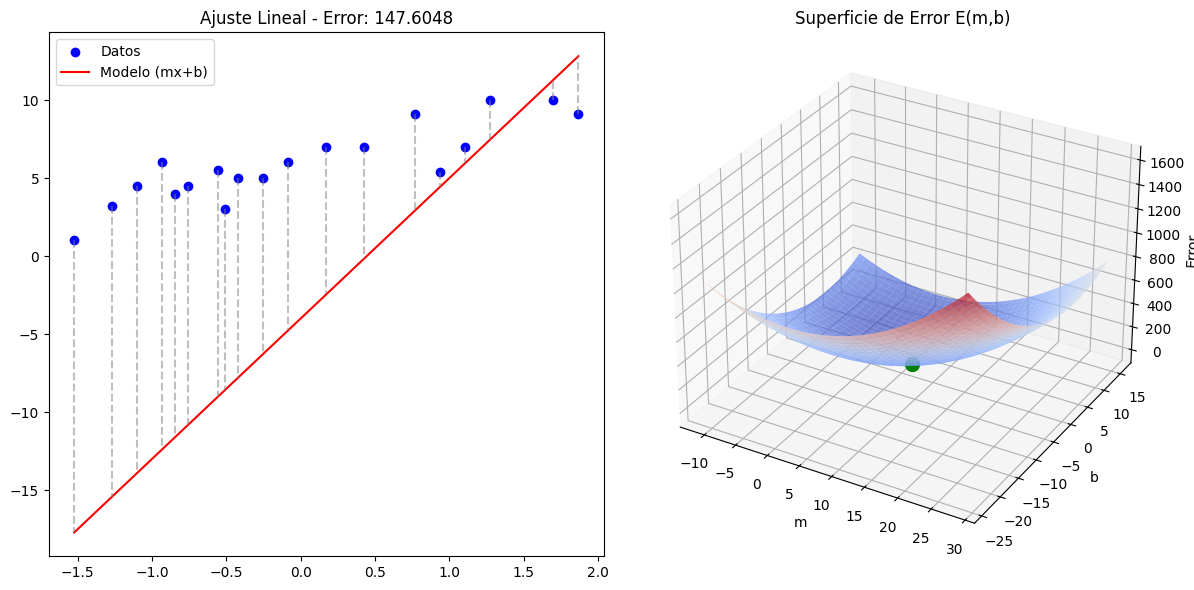

In [13]:
# Usamos una copia de los datos originales y normalizamos 'x'
x = x_original.copy()
y = y_original.copy()
x=(x-x.mean())/x.std()

# Cálculo de la salida o predicción del modelo para todos los ejemplos
y_predicted= x*m+b

# Calculo del error del modelo
errors= (y-y_predicted)**2
mean_error=errors.mean()

# Dato nuevo a evaluar con los parámetros actuales (considerando que new_x también debería normalizarse si se quisiera)
# Para este ejemplo, mantenemos new_x sin normalizar para ver el efecto directo en la visualización.
new_y=new_x*m+b

# Visualizar
visualizar(x,y,m,b,y_predicted,errors,mean_error,new_x,new_y,ver_residuos,ver_nuevo_dato)

Al normalizar la variable de entrada `x`, la forma de la superficie de error (derecha) se vuelve más simétrica y circular. Esto es crucial para los algoritmos de optimización como el descenso por gradiente, ya que permite que encuentren el mínimo de la función de costo de manera **más eficiente y estable**. La bola verde sigue indicando la posición actual de `m` y `b`, pero ahora en el contexto de los datos normalizados y una superficie de error más 'amigable' para la optimización.

## Frameworks de redes neuronales

### Keras

https://keras.io/

Deep learning for humans.
Keras is an API designed for human beings, not machines. Keras follows best practices for reducing cognitive load: it offers consistent & simple APIs, it minimizes the number of user actions required for common use cases, and it provides clear & actionable error messages. It also has extensive documentation and developer guides.

### Tensorflow

https://www.tensorflow.org/

An end-to-end machine learning platform

TensorFlow offers multiple levels of abstraction so you can choose the right one for your needs. Build and train models by using the high-level Keras API, which makes getting started with TensorFlow and machine learning easy.

### Pytorch

https://pytorch.org/

The Pytorch mission is to drive the adoption of AI and deep learning by supporting an open, vendor-neutral ecosystem built around PyTorch. By making state-of-the-art tools and libraries accessible to everyone, we aim to democratize innovation in AI and ML.

## Implementación con Keras (Red Neuronal Real)

Vamos a resolver el mismo problema de regresión pero utilizando una Red Neuronal de una sola capa (una neurona) con TensorFlow/Keras. El 'optimizer' (descenso por gradiente) y la 'loss' (error cuadrático medio) funcionan de la misma manera que la aplicada manualmente.

### Entrenamiento

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


El modelo aprendió: m = 1.6154, b = 5.1267


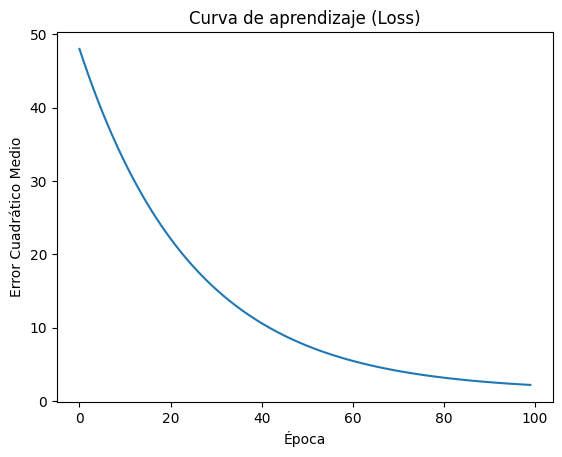

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Definir el modelo: Una red secuencial con 1 sola neurona
model = models.Sequential([
    layers.Dense(units=1, input_shape=[1])
])

# 2. Configurar el entrenamiento: Optimizador de descenso por gradiente y función de error
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mean_squared_error')

# 3. Entrenar el modelo con los datos normalizados (x)
history = model.fit(x, y, epochs=100, verbose=0)

# 4. Obtener los parámetros finales aprendidos por la red (nuestros m y b)
weights = model.get_weights()
m_learned = weights[0][0][0]
b_learned = weights[1][0]

print(f"El modelo aprendió: m = {m_learned:.4f}, b = {b_learned:.4f}")

# Visualizar la evolución del error
plt.plot(history.history['loss'])
plt.title('Curva de aprendizaje (Loss)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.show()

Esta es la **Curva de Aprendizaje**. Muestra cómo el error (Loss) disminuye en cada época de entrenamiento. La forma descendente indica que el optimizador está ajustando correctamente los pesos de la neurona para minimizar la diferencia entre la predicción y el valor real.

### Inferencia y visualizacion

In [15]:
# 1. Calcular las predicciones del modelo Keras
y_predicted_keras = model.predict(x).flatten()

# 2. Calcular el error para este modelo
errors_keras = (y - y_predicted_keras)**2
mean_error_keras = np.mean(errors_keras)

print(f"Error Cuadrático Medio del modelo Keras: {mean_error_keras:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Error Cuadrático Medio del modelo Keras: 2.1711


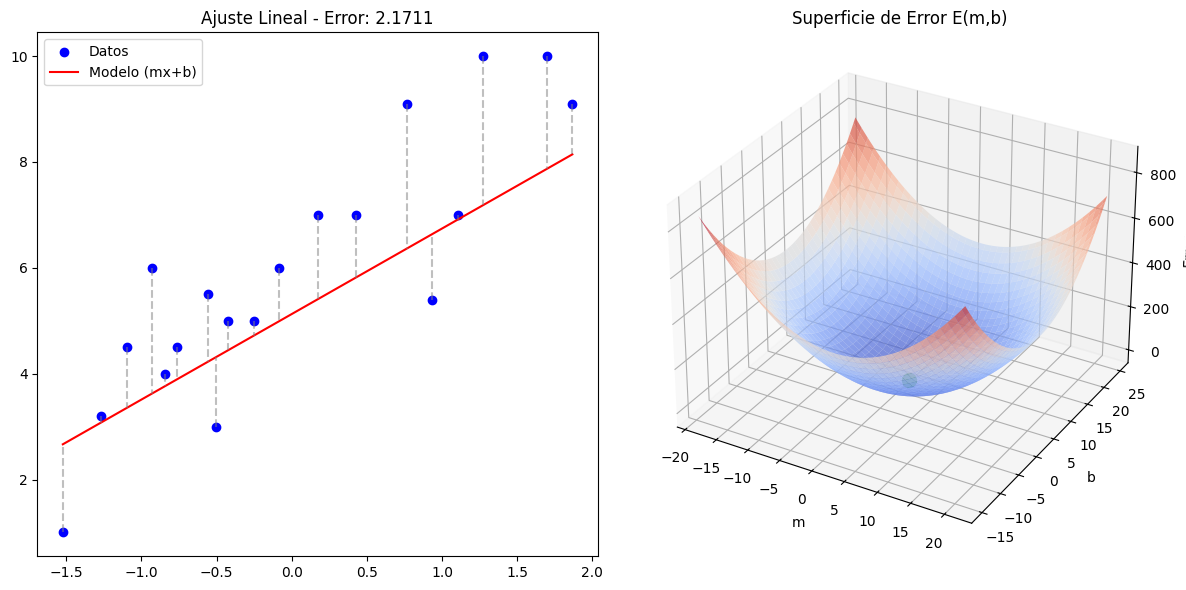

In [16]:
# 3. Visualizar el ajuste del modelo Keras
# Se usa 'x' normalizada para la visualización, ya que el modelo fue entrenado con ella.
visualizar(x, y, m_learned, b_learned, y_predicted_keras, errors_keras, mean_error_keras, new_x, new_y, ver_residuos, ver_nuevo_dato)

Este gráfico final muestra cómo la Red Neuronal (una sola neurona) entrenada con Keras ha ajustado la línea roja a los datos (puntos azules). La bola verde en la superficie de error indica la posición final de los parámetros `m` y `b` que la red aprendió, logrando un error mínimo. Observa cómo esta línea se ajusta mejor a los datos en comparación con las líneas ajustadas manualmente al inicio, lo que demuestra la efectividad del proceso de aprendizaje automático.